# Weather Forecast API / OPEN API

**Module Installation**

In [1]:
pip install requests-cache

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00


In [2]:
pip install retry-requests

In [3]:
pip install openmeteo-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 817.7/817.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.6 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


**Import**

In [4]:
import openmeteo_requests
import requests

import pandas as pd
import requests_cache
import matplotlib.pyplot as plt
from retry_requests import retry

In [5]:
url = "https://api.open-meteo.com/v1/forecast"  # ?latitude=35.1856&longitude=33.3823&hourly=temperature_2m,precipitation,wind_speed_10m&timezone=auto

params = {
    "latitude": 35.1856,
    "longitude": 33.3823,
    "hourly": "temperature_2m,precipitation,wind_speed_10m,shortwave_radiation",
    "timezone": "auto"
}

response = requests.get(url, params=params) # GET : URL + param
data = response.json()

data

# print(data["hourly"]["time"][0])
# print(data["hourly"]["temperature_2m"][0])

{'latitude': 35.1875,
 'longitude': 33.375,
 'generationtime_ms': 1.2526512145996094,
 'utc_offset_seconds': 10800,
 'timezone': 'Asia/Nicosia',
 'timezone_abbreviation': 'GMT+3',
 'elevation': 130.0,
 'hourly_units': {'time': 'iso8601',
  'temperature_2m': '°C',
  'precipitation': 'mm',
  'wind_speed_10m': 'km/h',
  'shortwave_radiation': 'W/m²'},
 'hourly': {'time': ['2026-08-27T00:00',
   '2026-08-27T01:00',
   '2026-08-27T02:00',
   '2026-08-27T03:00',
   '2026-08-27T04:00',
   '2026-08-27T05:00',
   '2026-08-27T06:00',
   '2026-08-27T07:00',
   '2026-08-27T08:00',
   '2026-08-27T09:00',
   '2026-08-27T10:00',
   '2026-08-27T11:00',
   '2026-08-27T12:00',
   '2026-08-27T13:00',
   '2026-08-27T14:00',
   '2026-08-27T15:00',
   '2026-08-27T16:00',
   '2026-08-27T17:00',
   '2026-08-27T18:00',
   '2026-08-27T19:00',
   '2026-08-27T20:00',
   '2026-08-27T21:00',
   '2026-08-27T22:00',
   '2026-08-27T23:00',
   '2026-08-28T00:00',
   '2026-08-28T01:00',
   '2026-08-28T02:00',
   '2026-0

In [6]:

df = pd.DataFrame(data)
df.head()


,latitude,longitude,generationtime_ms,utc_offset_seconds,timezone,timezone_abbreviation,elevation,hourly_units,hourly
time,35.1875,33.375,1.252651,10800,Asia/Nicosia,GMT+3,130.0,iso8601,"[2026-08-27T00:00, 2026-08-27T01:00, 2026-08-2..."
temperature_2m,35.1875,33.375,1.252651,10800,Asia/Nicosia,GMT+3,130.0,°C,"[26.3, 25.9, 25.6, 24.8, 24.1, 23.9, 23.7, 23...."
precipitation,35.1875,33.375,1.252651,10800,Asia/Nicosia,GMT+3,130.0,mm,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
wind_speed_10m,35.1875,33.375,1.252651,10800,Asia/Nicosia,GMT+3,130.0,km/h,"[6.1, 4.0, 2.3, 2.9, 1.5, 1.1, 1.1, 1.1, 1.6, ..."
shortwave_radiation,35.1875,33.375,1.252651,10800,Asia/Nicosia,GMT+3,130.0,W/m²,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 25.0, 168...."


In [7]:
hourly = data["hourly"]
hourly

{'time': ['2026-08-27T00:00',
  '2026-08-27T01:00',
  '2026-08-27T02:00',
  '2026-08-27T03:00',
  '2026-08-27T04:00',
  '2026-08-27T05:00',
  '2026-08-27T06:00',
  '2026-08-27T07:00',
  '2026-08-27T08:00',
  '2026-08-27T09:00',
  '2026-08-27T10:00',
  '2026-08-27T11:00',
  '2026-08-27T12:00',
  '2026-08-27T13:00',
  '2026-08-27T14:00',
  '2026-08-27T15:00',
  '2026-08-27T16:00',
  '2026-08-27T17:00',
  '2026-08-27T18:00',
  '2026-08-27T19:00',
  '2026-08-27T20:00',
  '2026-08-27T21:00',
  '2026-08-27T22:00',
  '2026-08-27T23:00',
  '2026-08-28T00:00',
  '2026-08-28T01:00',
  '2026-08-28T02:00',
  '2026-08-28T03:00',
  '2026-08-28T04:00',
  '2026-08-28T05:00',
  '2026-08-28T06:00',
  '2026-08-28T07:00',
  '2026-08-28T08:00',
  '2026-08-28T09:00',
  '2026-08-28T10:00',
  '2026-08-28T11:00',
  '2026-08-28T12:00',
  '2026-08-28T13:00',
  '2026-08-28T14:00',
  '2026-08-28T15:00',
  '2026-08-28T16:00',
  '2026-08-28T17:00',
  '2026-08-28T18:00',
  '2026-08-28T19:00',
  '2026-08-28T20:00',
  

In [8]:
df2 = pd.DataFrame({
    "time": hourly["time"],
    "temperature_2m": hourly["temperature_2m"],
    "precipitation": hourly["precipitation"],
    "wind_speed_10m": hourly["wind_speed_10m"],
    "shortwave_radiation": hourly["shortwave_radiation"],
})

df2.head(10)

,time,temperature_2m,precipitation,wind_speed_10m,shortwave_radiation
0,2026-08-27T00:00,26.3,0.0,6.1,0.0
1,2026-08-27T01:00,25.9,0.0,4.0,0.0
2,2026-08-27T02:00,25.6,0.0,2.3,0.0
3,2026-08-27T03:00,24.8,0.0,2.9,0.0
4,2026-08-27T04:00,24.1,0.0,1.5,0.0
5,2026-08-27T05:00,23.9,0.0,1.1,0.0
6,2026-08-27T06:00,23.7,0.0,1.1,0.0
7,2026-08-27T07:00,23.9,0.0,1.1,25.0
8,2026-08-27T08:00,25.6,0.0,1.6,168.0
9,2026-08-27T09:00,28.3,0.0,3.7,371.0


**Time convertion**

In [9]:
df2["time"] = pd.to_datetime(df2["time"])

In [10]:
df2["date"] = df2["time"].dt.date
df2["time"] = df2["time"].dt.time

In [11]:
df2.head()

,time,temperature_2m,precipitation,wind_speed_10m,shortwave_radiation,date
0,00:00:00,26.3,0.0,6.1,0.0,2026-08-27
1,01:00:00,25.9,0.0,4.0,0.0,2026-08-27
2,02:00:00,25.6,0.0,2.3,0.0,2026-08-27
3,03:00:00,24.8,0.0,2.9,0.0,2026-08-27
4,04:00:00,24.1,0.0,1.5,0.0,2026-08-27


In [12]:
df2 = df2[["date", "time", "temperature_2m", "wind_speed_10m", "precipitation", "shortwave_radiation"]]

df2

,date,time,temperature_2m,wind_speed_10m,precipitation,shortwave_radiation
0,2026-08-27,00:00:00,26.3,6.1,0.0,0.0
1,2026-08-27,01:00:00,25.9,4.0,0.0,0.0
2,2026-08-27,02:00:00,25.6,2.3,0.0,0.0
3,2026-08-27,03:00:00,24.8,2.9,0.0,0.0
4,2026-08-27,04:00:00,24.1,1.5,0.0,0.0
...,...,...,...,...,...,...
163,2026-09-02,19:00:00,31.8,6.8,0.0,81.0
164,2026-09-02,20:00:00,29.6,5.3,0.0,0.0
165,2026-09-02,21:00:00,27.8,7.7,0.0,0.0
166,2026-09-02,22:00:00,26.7,8.8,0.0,0.0


In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 168 non-null    object 
 1   time                 168 non-null    object 
 2   temperature_2m       168 non-null    float64
 3   wind_speed_10m       168 non-null    float64
 4   precipitation        168 non-null    float64
 5   shortwave_radiation  168 non-null    float64
dtypes: float64(4), object(2)
memory usage: 8.0+ KB


In [14]:
round(df2.describe(), 2)

,temperature_2m,wind_speed_10m,precipitation,shortwave_radiation
count,168.00,168.00,168.00,168.00
mean,28.67,7.25,0.02,270.31
std,4.43,3.66,0.15,328.89
min,21.40,1.10,0.00,0.00
25%,24.80,4.50,0.00,0.00
50%,27.70,6.85,0.00,52.00
75%,32.62,9.83,0.00,569.25
max,38.60,19.20,1.80,936.00


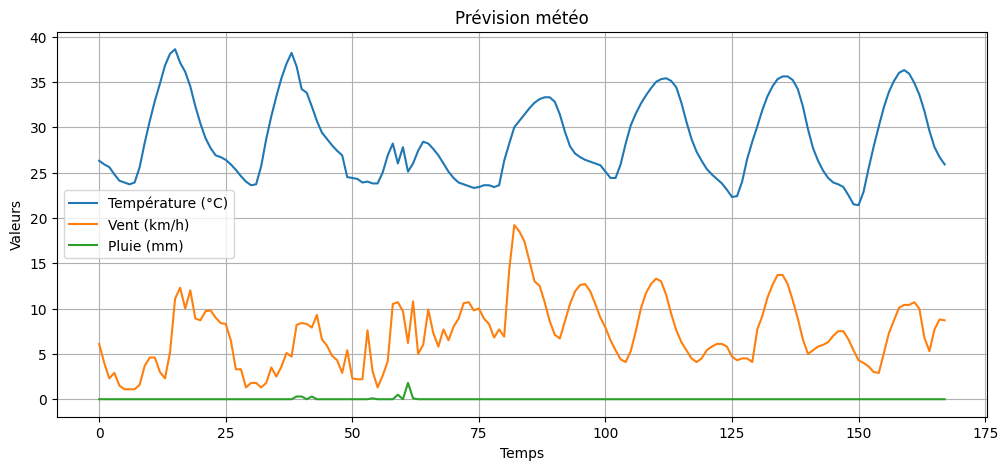

In [15]:
plt.figure(figsize=(12,5))

plt.plot(df2.index, df2["temperature_2m"], label="Température (°C)")
plt.plot(df2.index, df2["wind_speed_10m"], label="Vent (km/h)")
plt.plot(df2.index, df2["precipitation"], label="Pluie (mm)")

plt.title("Prévision météo")
plt.xlabel("Temps")
plt.ylabel("Valeurs")
plt.legend()
plt.grid(True)

plt.show()